In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Chemins
PROCESSED_PATH = '../data/processed/'
X = np.load(os.path.join(PROCESSED_PATH, 'X_train_sample.npy'))
Y = np.load(os.path.join(PROCESSED_PATH, 'Y_train_sample.npy'))

print(f"Dataset chargé : {X.shape[0]} patches de {X.shape[1]}x{X.shape[2]} pixels.")

Dataset chargé : 11 patches de 256x256 pixels.


Pixels Cibles (Blanc) : 42595 (5.91%)
Pixels Fond (Noir) : 678301 (94.09%)


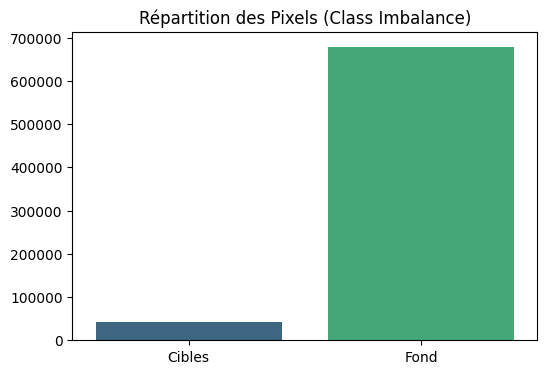

In [3]:
# Calculer le nombre de pixels "positifs" (routes/bâtiments) vs "négatifs"
total_pixels = Y.size
positive_pixels = np.sum(Y)
negative_pixels = total_pixels - positive_pixels

print(f"Pixels Cibles (Blanc) : {positive_pixels} ({positive_pixels/total_pixels:.2%})")
print(f"Pixels Fond (Noir) : {negative_pixels} ({negative_pixels/total_pixels:.2%})")

# Visualisation du ratio
plt.figure(figsize=(6, 4))
# Correction pour éviter le FutureWarning
sns.barplot(x=['Cibles', 'Fond'], y=[positive_pixels, negative_pixels], hue=['Cibles', 'Fond'], palette='viridis', legend=False)
plt.title("Répartition des Pixels (Class Imbalance)")
plt.show()

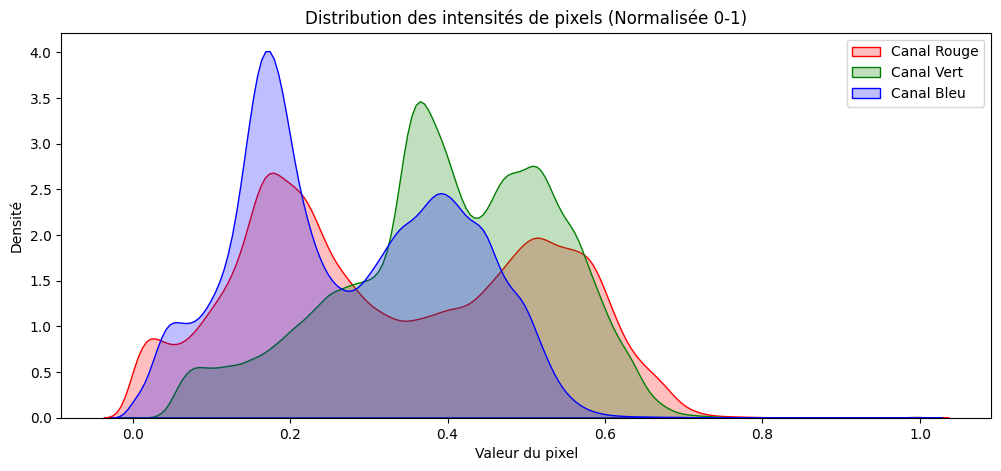

In [4]:
plt.figure(figsize=(12, 5))
colors = ['red', 'green', 'blue']
labels = ['Canal Rouge', 'Canal Vert', 'Canal Bleu']

for i in range(3):
    sns.kdeplot(X[:, :, :, i].flatten(), color=colors[i], label=labels[i], fill=True)

plt.title("Distribution des intensités de pixels (Normalisée 0-1)")
plt.xlabel("Valeur du pixel")
plt.ylabel("Densité")
plt.legend()
plt.show()

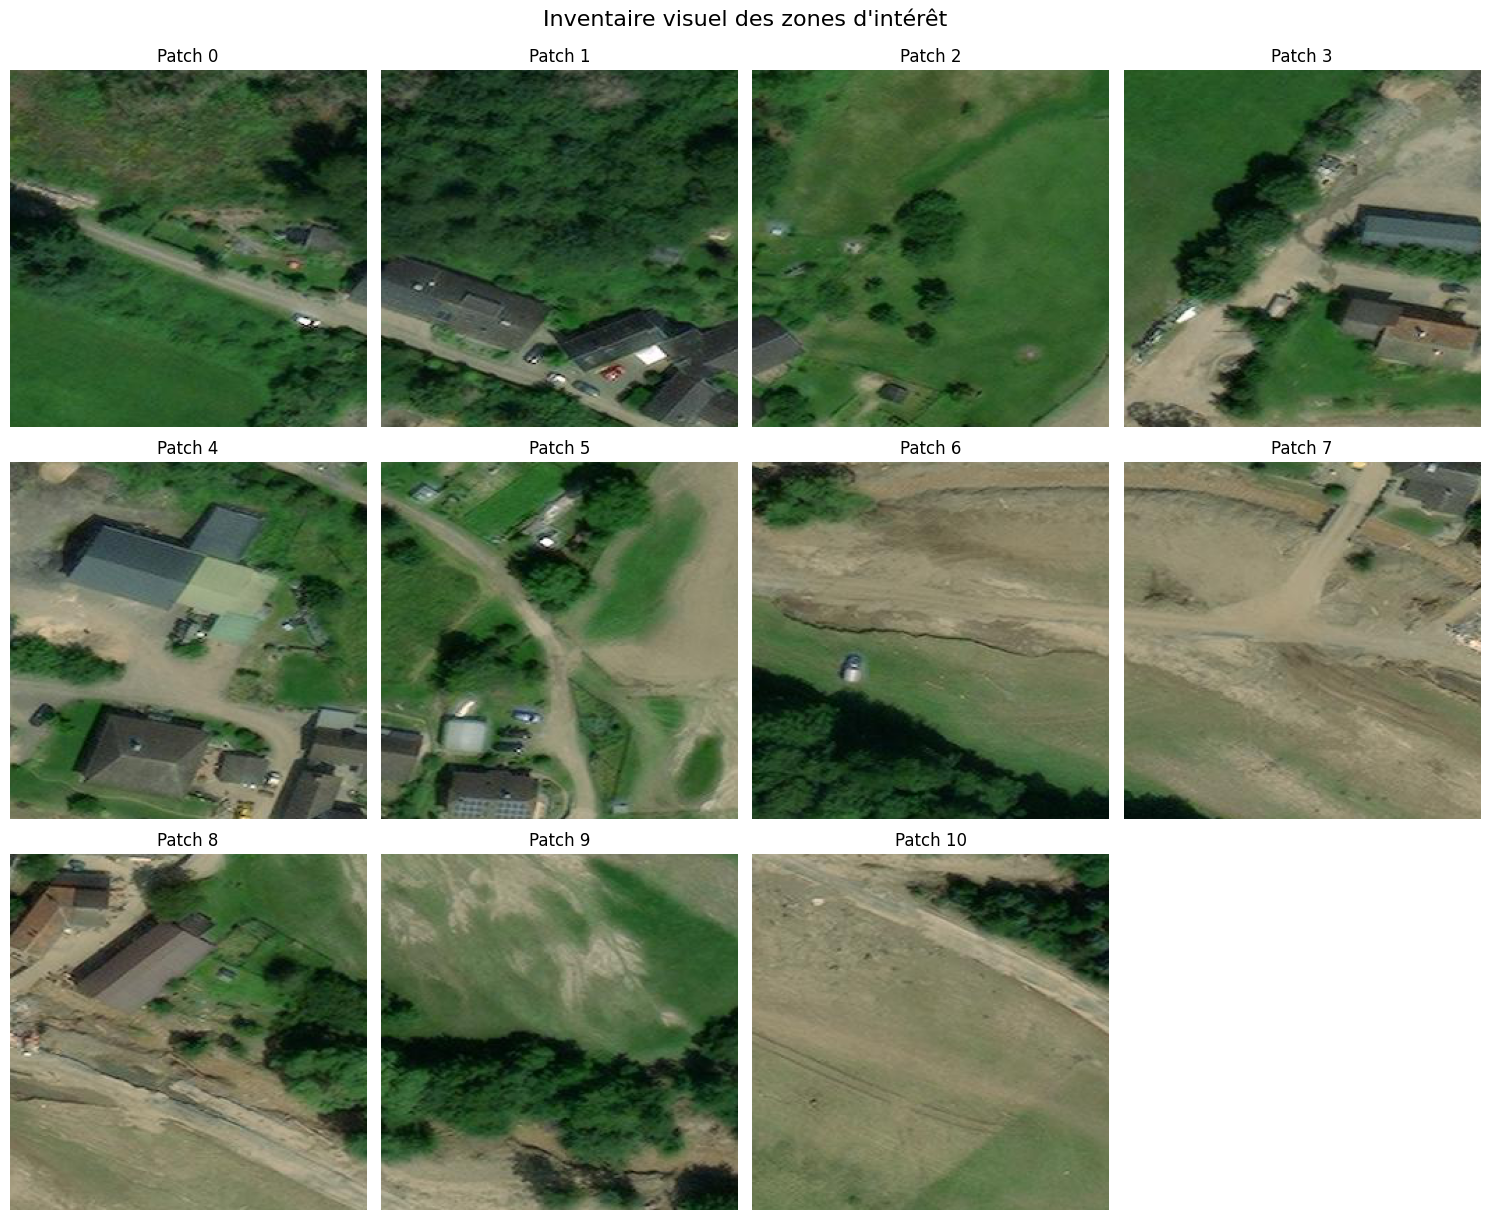

In [5]:
num_patches = X.shape[0]
cols = 4
rows = (num_patches // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i in range(num_patches):
    axes[i].imshow(X[i])
    axes[i].set_title(f"Patch {i}")
    axes[i].axis('off')

# Cacher les axes vides
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Inventaire visuel des zones d'intérêt", fontsize=16, y=1.02)
plt.show()